In [998]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [999]:
data_seq = pd.read_csv('pd_render_seq.csv')
data_par = pd.read_csv('pd_render_par.csv')
data_cs = pd.read_csv('pd_render_cs.csv')

In [1000]:
# Pick smallest and 4 largest
sorted_counts = sorted(data_seq["particle_count"])
special_labels = [sorted_counts[0]] + sorted_counts[-4:]

def custom_formatter(x, _):
    if x in special_labels:
        return f"$2^{{{int(np.log2(x))}}}$"
    else:
        return "" 

# Render Time

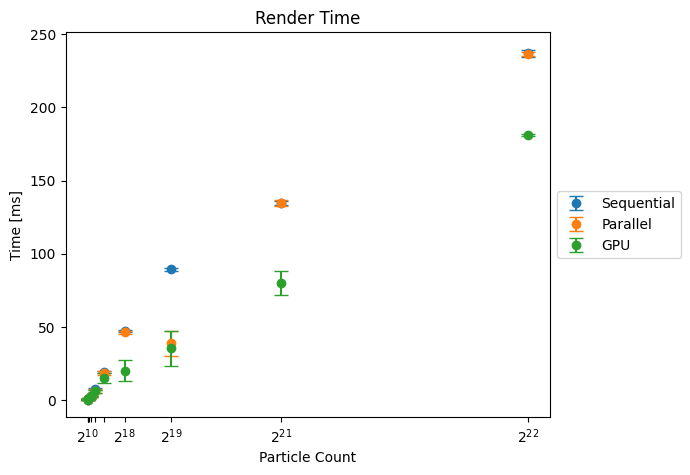

In [1001]:

fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_render"], data_seq["avg_time_render_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_render"], data_par["avg_time_render_err"], label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_render"], data_cs["avg_time_render_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Render Time")

axs.set_xticks(data_seq["particle_count"])
axs.xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("render_time.svg", format="svg")
plt.show()

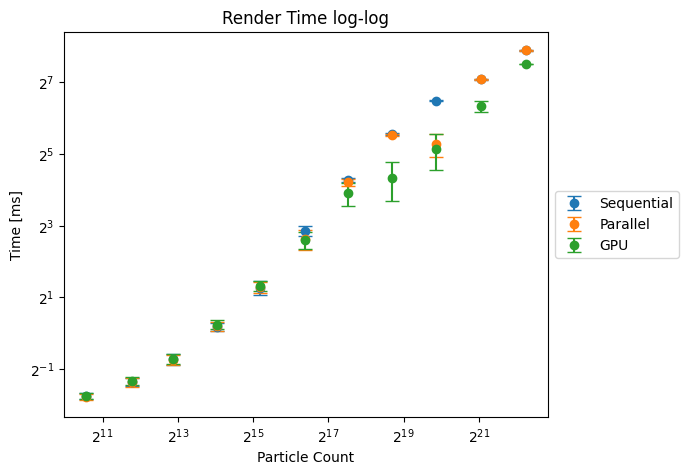

In [1002]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_render"], data_seq["avg_time_render_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_render"], data_par["avg_time_render_err"], label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_render"], data_cs["avg_time_render_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Render Time log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("render_time_log.svg", format="svg")
plt.show()

# Compute time

In [1003]:
import matplotlib.lines as mlines
from scipy.optimize import curve_fit

def fit_func(x, a, b):
    return a * x + b

In [1004]:
y_inter_c = []
y_inter_cpp = []
cols = ["tab:blue", "tab:orange", "tab:green"]

inter_labels = ["Slope - Sequential", "Slope - Parallel", "Slope - GPU"]


half_length = len(data_seq) // 3  # It ain't perfectly linear
popt_seq, pcov_seq = curve_fit(fit_func, data_seq["particle_count"][:half_length], data_seq["avg_time_compute_cpu"][:half_length], sigma=data_seq["avg_time_compute_cpu_err"][:half_length], absolute_sigma=True)
popt_par, pcov_par = curve_fit(fit_func, data_par["particle_count"][:half_length], data_par["avg_time_compute_cpu"][:half_length] / 8, sigma=data_par["avg_time_compute_cpu_err"][:half_length] / 8, absolute_sigma=True)
popt_cs, pcov_cs = curve_fit(fit_func, data_cs["particle_count"][:half_length], data_cs["avg_time_compute"][:half_length], sigma=data_cs["avg_time_compute_err"][:half_length], absolute_sigma=True)

half_length = len(data_seq) // 4  # It ain't perfectly linear
popt_seq_pp, pcov_seq_pp = curve_fit(fit_func, data_seq["particle_count"][:half_length], data_seq["avg_time_per_particle_compute_cpu"][:half_length], sigma=data_seq["avg_time_per_particle_compute_cpu_err"][:half_length], absolute_sigma=True)
popt_par_pp, pcov_par_pp = curve_fit(fit_func, data_par["particle_count"][:half_length], data_par["avg_time_per_particle_compute_cpu"][:half_length] / 8, sigma=data_par["avg_time_per_particle_compute_cpu_err"][:half_length] / 8, absolute_sigma=True)
popt_cs_pp, pcov_cs_pp = curve_fit(fit_func, data_cs["particle_count"][:half_length], data_cs["avg_time_per_particle_compute"][:half_length], sigma=data_cs["avg_time_per_particle_compute_err"][:half_length], absolute_sigma=True)



y_inter_c.append((lambda x: fit_func(x, *popt_seq))(0))
y_inter_c.append((lambda x: fit_func(x, *popt_par))(0))
y_inter_c.append((lambda x: fit_func(x, *popt_cs))(0))

y_inter_cpp.append((lambda x: fit_func(x, *popt_seq_pp))(0))
y_inter_cpp.append((lambda x: fit_func(x, *popt_par_pp))(0))
y_inter_cpp.append((lambda x: fit_func(x, *popt_cs_pp))(0))

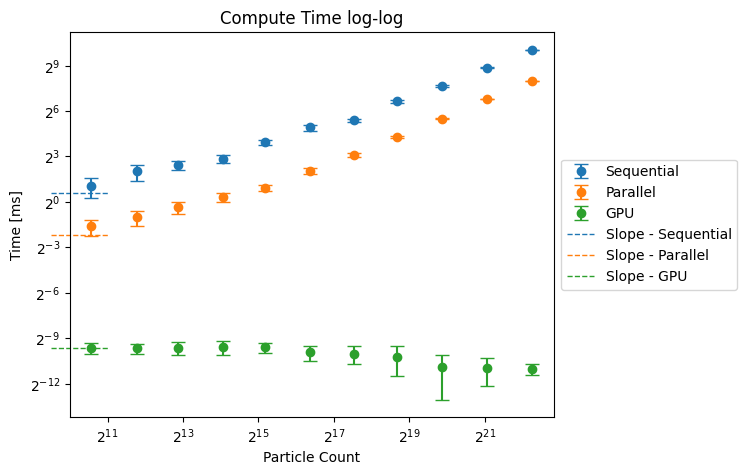

In [1005]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_compute_cpu"], yerr=data_seq["avg_time_compute_cpu_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_compute_cpu"]/8, yerr=data_par["avg_time_compute_cpu_err"]/8, label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_compute"], yerr=data_cs["avg_time_compute_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Compute Time log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

# This is very hacky, but idk how to do it otherwise
axs.set_xlim(left=2**10)
ticks = [2**i for i in range(11, 22, 2)]
axs.set_xticks(ticks)
axs.set_xticklabels([f"$2^{{{int(np.log2(tick))}}}$" for tick in ticks])

legend_lines = []
for i, (label, y) in enumerate(zip(inter_labels, y_inter_c)):
    axs.hlines(y, xmin=2**9.7, xmax=2**11, colors=cols[i], linewidth=1, linestyle='--')
    axs.plot([2**9.5, 2**10], [y, y], color=cols[i], linewidth=1, clip_on=False, linestyle="--")  # Extend the line outside the graph
    line = mlines.Line2D([], [], color=cols[i], linestyle='--', linewidth=1, label=label)
    legend_lines.append(line)

handles, existing_labels = axs.get_legend_handles_labels()
handles.extend(legend_lines)
existing_labels.extend(inter_labels)

axs.legend(handles, existing_labels, loc="center left", bbox_to_anchor=(1, 0.5))

# plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.savefig("compute_time_log.svg", format="svg")
plt.show()

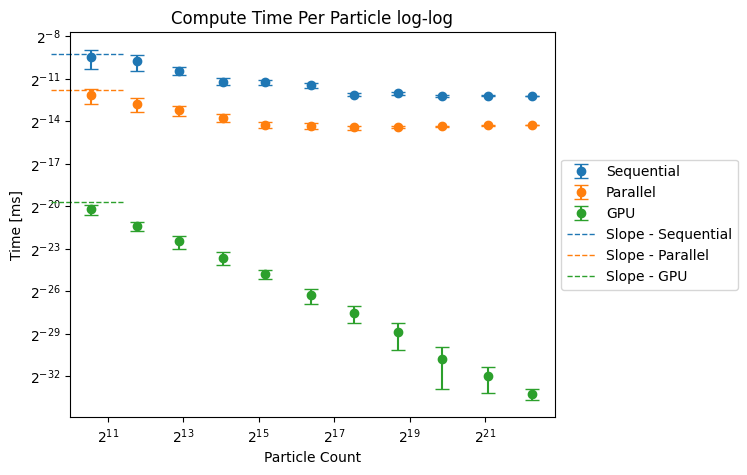

In [1006]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_per_particle_compute_cpu"], yerr=data_seq["avg_time_per_particle_compute_cpu_err"], label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_per_particle_compute_cpu"]/8, yerr=data_par["avg_time_per_particle_compute_cpu_err"]/8, label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_per_particle_compute"], yerr=data_cs["avg_time_per_particle_compute_err"], label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Compute Time Per Particle log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

# This is very hacky, but idk how to do it otherwise
axs.set_xlim(left=2**10)
ticks = [2**i for i in range(11, 22, 2)]
axs.set_xticks(ticks)
axs.set_xticklabels([f"$2^{{{int(np.log2(tick))}}}$" for tick in ticks])

legend_lines = []
for i, (label, y) in enumerate(zip(inter_labels, y_inter_cpp)):
    axs.hlines(y, xmin=2**9.7, xmax=2**11.4, colors=cols[i], linewidth=1, linestyle='--')
    axs.plot([2**9.5, 2**10], [y, y], color=cols[i], linewidth=1, clip_on=False, linestyle="--")  # Extend the line outside the graph
    line = mlines.Line2D([], [], color=cols[i], linestyle='--', linewidth=1, label=label)
    legend_lines.append(line)

handles, existing_labels = axs.get_legend_handles_labels()
handles.extend(legend_lines)
existing_labels.extend(inter_labels)

axs.legend(handles, existing_labels, loc="center left", bbox_to_anchor=(1, 0.5))

# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("compute_time_pp_log.svg", format="svg")
plt.show()

# Application Cycle Time

Sequential fit slope: 2.691e-04 +/- 2.710e-06
Parallel fit slope: 1.021e-04 +/- 5.861e-07
GPU fit slope: 3.619e-05 +/- 8.970e-08


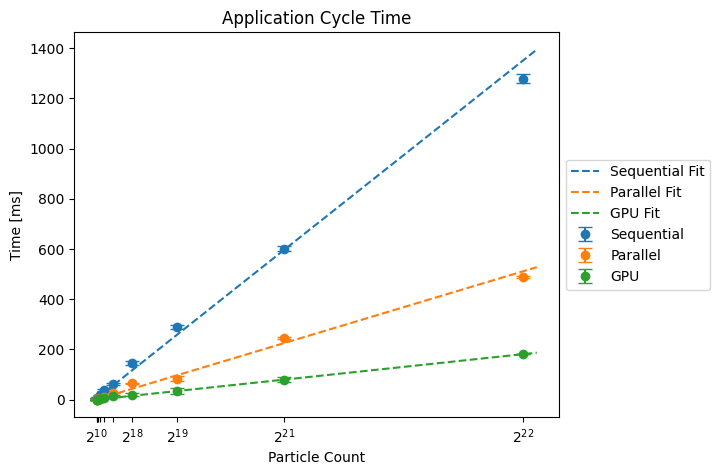

In [1007]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

ys_seq = data_seq["avg_time_compute_cpu"] + data_seq["avg_time_render"]
ys_par = data_par["avg_time_compute_cpu"]/8 + data_par["avg_time_render"]
ys_cs = data_cs["avg_time_compute"] + data_cs["avg_time_render"]
ys_seq_err = np.sqrt(data_seq["avg_time_compute_cpu_err"]**2 + data_seq["avg_time_render_err"]**2)
ys_par_err = np.sqrt((data_par["avg_time_compute_cpu_err"]/8)**2 + data_par["avg_time_render_err"]**2)
ys_cs_err = np.sqrt(data_cs["avg_time_compute_err"]**2 + data_cs["avg_time_render_err"]**2)

axs.errorbar(data_seq["particle_count"], ys_seq, ys_seq_err, label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], ys_par, ys_par_err, label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], ys_cs, ys_cs_err, label="GPU", fmt='o', capsize=5)

popt_seq, pcov_seq = curve_fit(fit_func, data_seq["particle_count"], ys_seq, sigma=ys_seq_err, absolute_sigma=True)
popt_par, pcov_par = curve_fit(fit_func, data_par["particle_count"], ys_par, sigma=ys_par_err, absolute_sigma=True)
popt_cs, pcov_cs = curve_fit(fit_func, data_cs["particle_count"], ys_cs, sigma=ys_cs_err, absolute_sigma=True)

print(f"Sequential fit slope: {popt_seq[0]:.3e} +/- {np.sqrt(np.diag(pcov_seq))[0]:.3e}")
print(f"Parallel fit slope: {popt_par[0]:.3e} +/- {np.sqrt(np.diag(pcov_par))[0]:.3e}")
print(f"GPU fit slope: {popt_cs[0]:.3e} +/- {np.sqrt(np.diag(pcov_cs))[0]:.3e}")

x_fit = np.linspace(0, 2**22.3, 10000)
axs.plot(x_fit, fit_func(x_fit, *popt_seq), label="Sequential Fit", linestyle='--', color='tab:blue')
axs.plot(x_fit, fit_func(x_fit, *popt_par), label="Parallel Fit", linestyle='--', color='tab:orange')
axs.plot(x_fit, fit_func(x_fit, *popt_cs), label="GPU Fit", linestyle='--', color='tab:green')

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Application Cycle Time")

axs.set_xticks(data_seq["particle_count"])
axs.xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("app_cycle_time.svg", format="svg")
plt.show()


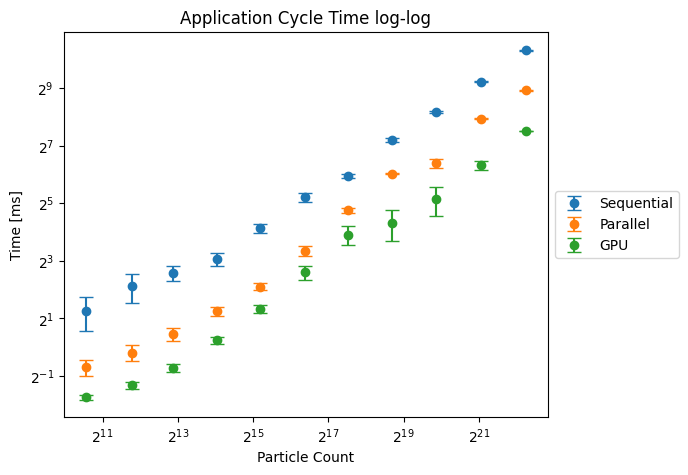

In [1008]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(data_seq["particle_count"], data_seq["avg_time_compute_cpu"] + data_seq["avg_time_render"], np.sqrt(data_seq["avg_time_compute_cpu_err"]**2 + data_seq["avg_time_render_err"]**2), label="Sequential", fmt='o', capsize=5)
axs.errorbar(data_par["particle_count"], data_par["avg_time_compute_cpu"]/8 + data_par["avg_time_render"], np.sqrt((data_par["avg_time_compute_cpu_err"]/8)**2 + data_par["avg_time_render_err"]**2), label="Parallel", fmt='o', capsize=5)
axs.errorbar(data_cs["particle_count"], data_cs["avg_time_compute"] + data_cs["avg_time_render"], np.sqrt(data_cs["avg_time_compute_err"]**2 + data_cs["avg_time_render_err"]**2), label="GPU", fmt='o', capsize=5)

axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")
axs.set_title("Application Cycle Time log-log")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("app_cycle_time_log.svg", format="svg")
plt.show()


# Wall Clock time

In [1009]:
wall_seq = pd.read_csv('wall_seq.csv')
wall_par = pd.read_csv('wall_par.csv')
wall_cs = pd.read_csv('wall_cs.csv')

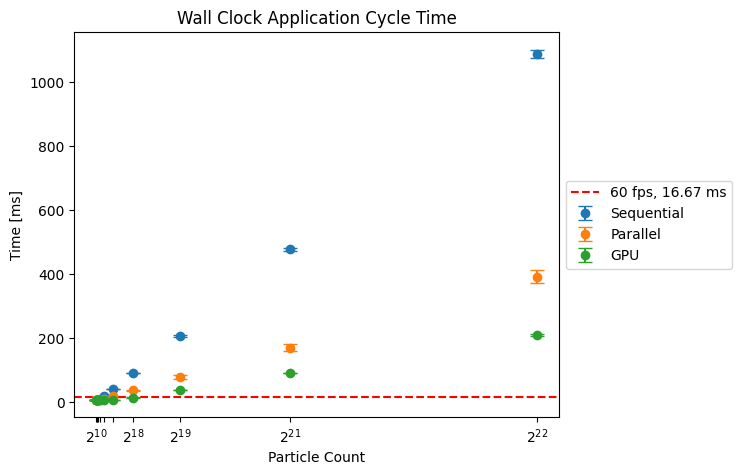

In [1010]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(wall_seq["particle_count"], wall_seq["avg_time"], yerr=wall_seq["avg_time_err"], fmt='o', label=f"Sequential", capsize=5)
axs.errorbar(wall_par["particle_count"], wall_par["avg_time"], yerr=wall_par["avg_time_err"], fmt='o', label=f"Parallel", capsize=5)
axs.errorbar(wall_cs["particle_count"], wall_cs["avg_time"], yerr=wall_cs["avg_time_err"], fmt='o', label=f"GPU", capsize=5)

# Red dashed line at 16.67 ms
axs.axhline(y=16.67, color='r', linestyle='--', label="60 fps, 16.67 ms")

axs.set_title("Wall Clock Application Cycle Time")
axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")

axs.set_xticks(wall_seq["particle_count"])
axs.xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("wall_clock.svg", format="svg")
plt.show()

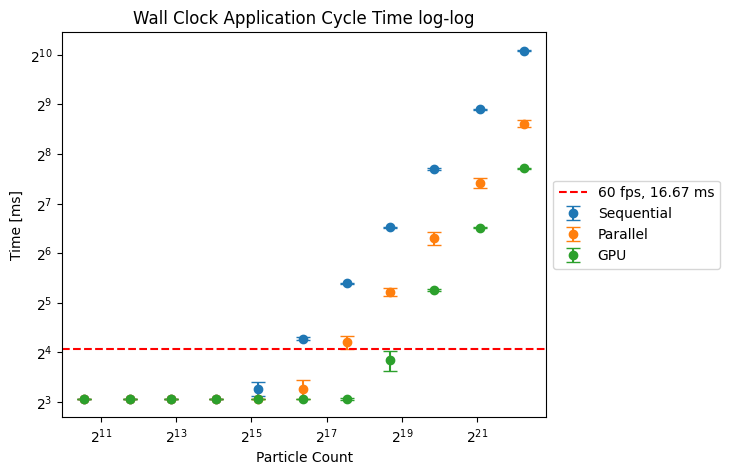

In [1011]:
fig, axs = plt.subplots(1, 1, figsize=(6.25, 5))

axs.errorbar(wall_seq["particle_count"], wall_seq["avg_time"], yerr=wall_seq["avg_time_err"], fmt='o', label=f"Sequential", capsize=5)
axs.errorbar(wall_par["particle_count"], wall_par["avg_time"], yerr=wall_par["avg_time_err"], fmt='o', label=f"Parallel", capsize=5)
axs.errorbar(wall_cs["particle_count"], wall_cs["avg_time"], yerr=wall_cs["avg_time_err"], fmt='o', label=f"GPU", capsize=5)

# Red dashed line at 16.67 ms
axs.axhline(y=16.67, color='r', linestyle='--', label="60 fps, 16.67 ms")

axs.set_title("Wall Clock Application Cycle Time log-log")
axs.set_xlabel("Particle Count")
axs.set_ylabel("Time [ms]")

axs.set_xscale("log", base=2)
axs.set_yscale("log", base=2)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("wall_clock_log.svg", format="svg")
plt.show()

# The histograms

In [1012]:
hist_seq = pd.read_csv('hist_seq.csv')
hist_par = pd.read_csv('hist_par.csv')
hist_cs = pd.read_csv('hist_cs.csv')

particle_counts = [1500, 3500, 7500, 17000, 37000, 85000, 190000, 420000, 950000, 2200000, 5000000]
modes = ["computeShaders", "sequential", "parallel"]

avg % = 0.035


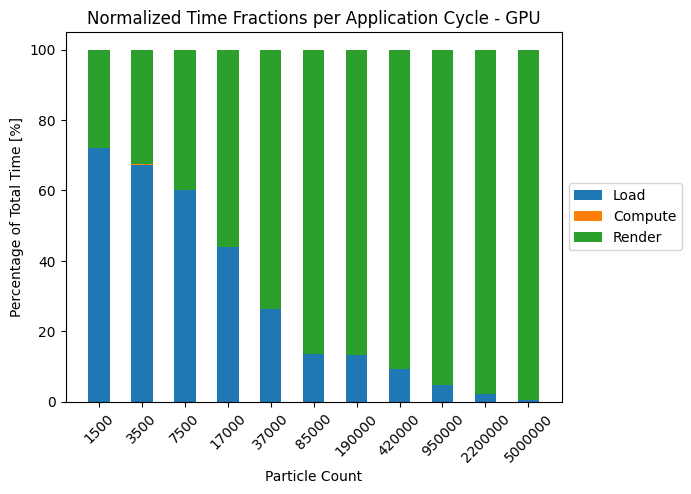

In [1013]:
# Stacked bars compute shaders
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(hist_cs["avg_time_cpu"])[0:chunk] / 2,
    "Compute": np.array(hist_cs["avg_time_compute"])[0:chunk],
    "Render": np.array(hist_cs["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}
print(f"avg % = {sum(normalized_weights["Compute"])/11:.3f}")
width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')

ax.set_title('Normalized Time Fractions per Application Cycle - GPU')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("hist_cs.svg", format="svg")
plt.show()

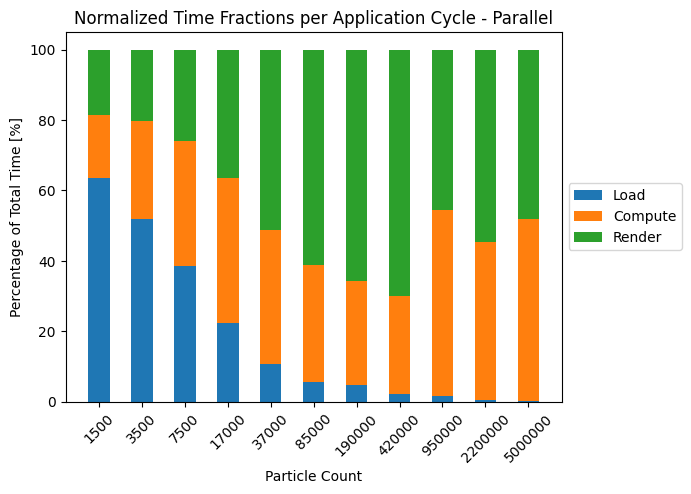

In [1014]:
# Stacked bars parallel
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(hist_par["avg_time_cpu"] - hist_par["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(hist_par["avg_time_compute_cpu"])[0:chunk]/8,
    "Render": np.array(hist_par["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')

ax.set_title('Normalized Time Fractions per Application Cycle - Parallel')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("hist_par.svg", format="svg")
plt.show()

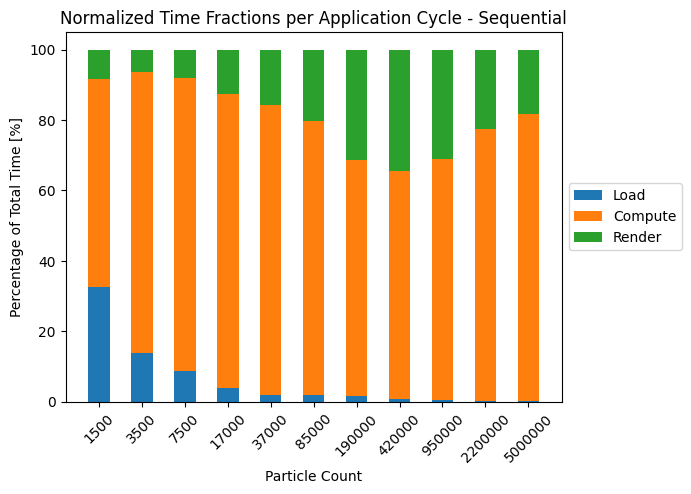

In [1015]:
# Stacked bars sequential
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(hist_seq["avg_time_cpu"] - hist_seq["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(hist_seq["avg_time_compute_cpu"])[0:chunk],
    "Render": np.array(hist_seq["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')
ax.set_title('Normalized Time Fractions per Application Cycle - Sequential')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("hist_seq.svg", format="svg")
plt.show()